<a href="https://colab.research.google.com/github/poojask27/MachineLearning-Lab2-73-/blob/main/ML2_2nd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files
import pandas as pd

# Upload the Kaggle CSV file
uploaded = files.upload()

# Automatically get the uploaded filename
filename = list(uploaded.keys())[0]

# Read the dataset
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("File name:", filename)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Saving Pass-Fail Data.csv to Pass-Fail Data.csv
Dataset loaded successfully!
File name: Pass-Fail Data.csv

First 5 rows:


,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0



Dataset shape:
(100, 6)

Column names:
['student_id', 'attendance_pct', 'homework_pct', 'midterm_score', 'study_hours_per_week', 'pass']


In [6]:
print(df.isnull().sum())

student_id              0
attendance_pct          0
homework_pct            0
midterm_score           0
study_hours_per_week    0
pass                    0
dtype: int64


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            100 non-null    int64
 1   attendance_pct        100 non-null    int64
 2   homework_pct          100 non-null    int64
 3   midterm_score         100 non-null    int64
 4   study_hours_per_week  100 non-null    int64
 5   pass                  100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB
None


STUDENT PASS/FAIL DATASET


,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0
5,6,85,90,91,14,1
6,7,78,80,74,8,1
7,8,55,60,62,5,0
8,9,90,88,84,11,1
9,10,68,65,60,6,1



Dataset Shape:
(100, 6)

Missing Values:
student_id              0
attendance_pct          0
homework_pct            0
midterm_score           0
study_hours_per_week    0
pass                    0
dtype: int64

Features:
['attendance_pct', 'homework_pct', 'midterm_score', 'study_hours_per_week']

Target:
pass

Training Samples: 80
Testing Samples : 20

Model trained successfully!

Actual Values:
[1 1 1 1 0 0 0 1 0 0 0 1 0 1 0 1 1 1 1 1]

Predicted Values:
[1 1 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 1 1]

MODEL PERFORMANCE
Accuracy  : 0.95
Precision : 1.00
Recall    : 0.92
F1-Score  : 0.96

Confusion Matrix:
[[ 8  0]
 [ 1 11]]


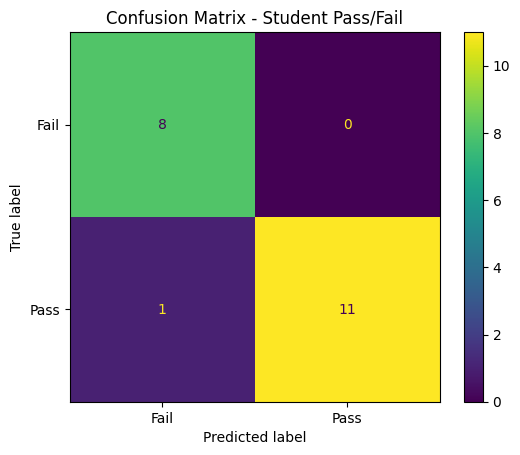

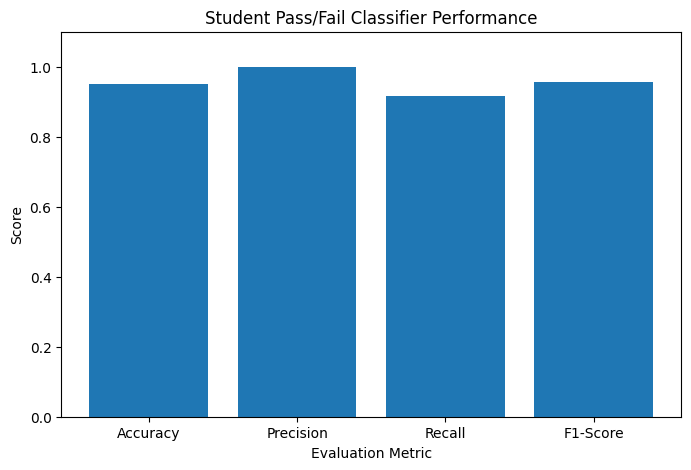

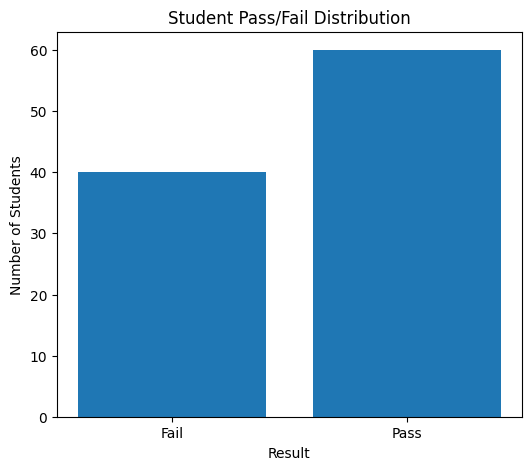

In [8]:
# ============================================================
# PROGRAM 2: BASIC SUPERVISED LEARNING PIPELINE
# Dataset: Student Pass/Fail Data
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. DISPLAY DATASET
# ============================================================

print("STUDENT PASS/FAIL DATASET")
print("=" * 60)

display(df.head(10))

print("\nDataset Shape:")
print(df.shape)


# ============================================================
# 2. CHECK FOR MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 3. SEPARATE FEATURES AND TARGET
# ============================================================

# student_id is only an identifier, so we don't use it
# as a feature.

X = df[
    [
        "attendance_pct",
        "homework_pct",
        "midterm_score",
        "study_hours_per_week"
    ]
]

y = df["pass"]


print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("pass")


# ============================================================
# 4. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ============================================================
# 5. CREATE CLASSIFIER
# ============================================================

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)


# ============================================================
# 6. TRAIN THE MODEL
# ============================================================

model.fit(X_train, y_train)

print("\nModel trained successfully!")


# ============================================================
# 7. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

print("\nActual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)


# ============================================================
# 8. CALCULATE METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


# ============================================================
# 9. DISPLAY PERFORMANCE
# ============================================================

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1-Score  : {f1:.2f}")


# ============================================================
# 10. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 11. PLOT CONFUSION MATRIX
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot()

plt.title("Confusion Matrix - Student Pass/Fail")

plt.show()


# ============================================================
# 12. GRAPH - PERFORMANCE METRICS
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

values = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(8, 5))

plt.bar(
    metrics,
    values
)

plt.ylim(0, 1.1)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.title("Student Pass/Fail Classifier Performance")

plt.show()


# ============================================================
# 13. GRAPH - PASS/FAIL DISTRIBUTION
# ============================================================

pass_count = df["pass"].value_counts()

plt.figure(figsize=(6, 5))

plt.bar(
    ["Fail", "Pass"],
    [
        pass_count.get(0, 0),
        pass_count.get(1, 0)
    ]
)

plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.title("Student Pass/Fail Distribution")

plt.show()